# Assignment 1: Data Exploration & Preprocessing

## Wo befinden wir uns im MLOps-Projekt?

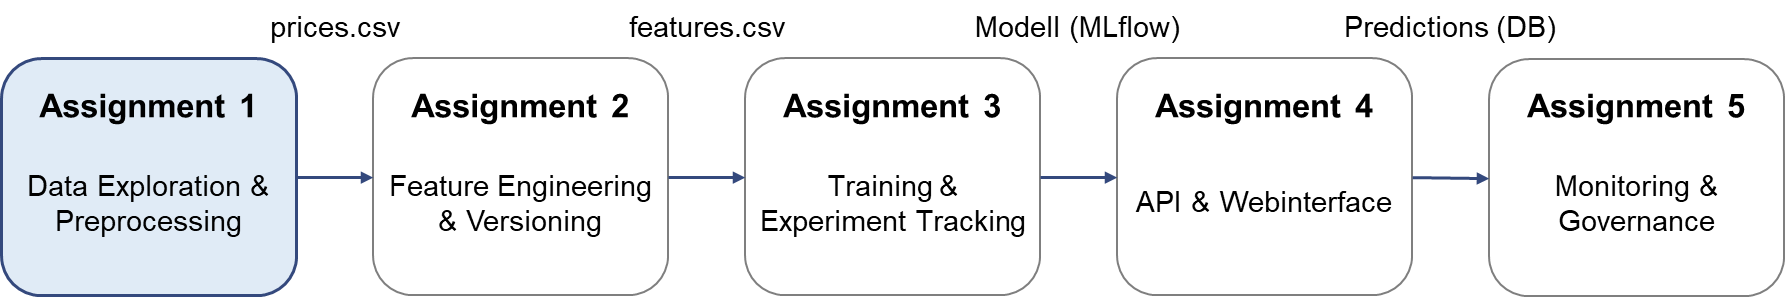

## Was passiert in diesem Notebook?

Sie laden stündliche Kraftstoffpreise (E5/E10/Diesel) für Ihre Tankstelle aus einer PostgreSQL-Datenbank und bereiten sie für das Feature Engineering in A2 auf. Die Rohdaten liegen als *sparse changes* vor – es wird nur ein Eintrag gespeichert, wenn sich der Preis ändert. Dieser wird auf ein gleichmäßiges stündliches Raster umgerechnet.

**Voraussetzung:** A0 abgeschlossen (`STATION_ID` und `FUEL_TYPE` in `config.py` gesetzt, DB-Verbindung funktioniert)  
**Ausgabe:** `data/raw/prices.csv`  

---

**Funktionen zu implementieren:**
| Funktion | Beschreibung |
|---|---|
| `fetch_price_history()` | Preisänderungen per SQL aus PostgreSQL laden |
| `resample_to_hourly()` | Sparse Preisänderungen → stündliches Raster (forward-fill) |
| `run_ingestion()` | Orchestrierung → `prices.csv` speichern |

## Bewertungskriterien (8 Punkte)

| Kriterium | Punkte |
|---|---|
| `fetch_price_history()`: SQL-Abfrage aus `gasprices`-Schema, korrekte Spalten, UTC-aware Datetime | 3 |
| `resample_to_hourly()`: Stündliches Raster, Forward-Fill, Milli-Euro → EUR/L, keine NaN | 3 |
| Code-Qualität & Dokumentation (Docstrings, Variablennamen) | 2 |
| **Gesamt** | **8** |

**Abgabe: 09.04.2026 um 23:59 Uhr**

---

### Was wird technisch geprüft?

Nach Ihrer Implementierung muss `data/raw/prices.csv` folgende Eigenschaften haben:
- Spalten: `datetime` (UTC-aware) und `{FUEL_TYPE}_price` (EUR/L, z.B. `e5_price`)
- Keine NaN-Werte (Forward-Fill nach Resampling)
- Stündliche Frequenz (genau 1h zwischen jedem Eintrag)
- Mindestens 1.000 Einträge (entspricht ~41 Tagen Preishistorie)
- Preisbereich: 1.0–3.0 EUR/L (nicht in Milli-Euro!)

In [ ]:
import os, sys

_cwd = os.getcwd()
PROJECT_ROOT = _cwd if os.path.exists(os.path.join(_cwd, "config.py")) \
               else os.path.abspath(os.path.join(_cwd, ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import psycopg2

from config import GROUP_ID, STATION_ID, FUEL_TYPE, DB_CONFIG, GASPRICES_SCHEMA, DEFAULT_PARAMS

params = DEFAULT_PARAMS
paths  = params["paths"]

print(f"Gruppe     : {GROUP_ID}")
print(f"Station    : {STATION_ID}")
print(f"Kraftstoff : {FUEL_TYPE}")
print(f"Quelle     : {GASPRICES_SCHEMA}.gas_station_information_history")
print(f"Ziel       : {paths['raw_prices']}")

---
## Exploration (nicht benotet)

Bevor Sie mit der Implementierung beginnen, erkunden Sie die vorliegenden Daten.
Dieser Schritt ist immer zuerst durchzuführen, um ein Gefühl für die Daten zu erhalten. Wichtige Fragestellungen sind beispielsweise:
- Haben die Daten viele Ausreißer?
- Gibt es Anhäufungen von Daten um einen bestimmten Bereich?
- Müssen die Daten auf eine bestimmte Art und Weise aufbereitet werden, damit man sie überhaupt gewinnbringend analysieren kann?

**Was Sie herausfinden sollten:**
- Wie viele Preisänderungen gibt es für Ihre Tankstelle?
- In welchem Zeitraum liegen die Daten?
- Wie sehen typische Kraftstoffpreise aus (min, max, Durchschnitt)?
- Wie oft ändert sich der Preis (Stunden zwischen Änderungen)?

Fügen Sie nach dieser Zelle weitere Zellen ein und analysieren Sie die Daten grundlegend.

In [ ]:
# Exploration: Datenbankstruktur erkunden (nicht benotet)
import psycopg2
conn_explore = psycopg2.connect(**DB_CONFIG)
cur = conn_explore.cursor()

# Anzahl Einträge für diese Tankstelle
cur.execute(f"""
    SELECT COUNT(*), MIN(date), MAX(date)
    FROM {GASPRICES_SCHEMA}.gas_station_information_history
    WHERE stid = %s AND {FUEL_TYPE} IS NOT NULL AND {FUEL_TYPE} > 0
""", (STATION_ID,))
count, min_date, max_date = cur.fetchone()
print(f"Preisänderungen : {count:,}")
print(f"Zeitraum        : {min_date} bis {max_date}")

# Erste Zeilen anschauen
import pandas as pd
df_explore = pd.read_sql(f"""
    SELECT stid, date, {FUEL_TYPE}
    FROM {GASPRICES_SCHEMA}.gas_station_information_history
    WHERE stid = %(sid)s AND {FUEL_TYPE} IS NOT NULL AND {FUEL_TYPE} > 0
    ORDER BY date DESC
    LIMIT 10
""", conn_explore, params={"sid": STATION_ID})
conn_explore.close()

df_explore[f"{FUEL_TYPE}_eur"] = df_explore[FUEL_TYPE] / 1000.0
print(f"\nLetzte 10 Preisänderungen:")
print(df_explore[["date", FUEL_TYPE, f"{FUEL_TYPE}_eur"]].to_string(index=False))

---
## TODO (1/3): `fetch_price_history()`

### Aufgabe

`fetch_price_history()` lädt alle Preisänderungen einer Tankstelle aus der Datenbank.
Das ist der erste Schritt der gesamten Datenpipeline – ohne Rohdaten keine Features, kein Training.

### Hintergrund

Die Tabelle `gasprices.gas_station_information_history` speichert Preise als *sparse changes*:
Es wird nur ein Eintrag gespeichert, wenn sich der Preis ändert – nicht jede Stunde.
Die Preise liegen als Integer in Milli-Euro vor (z.B. 1819 = 1,819 EUR/L).

```
Tabelle: gasprices.gas_station_information_history
Spalten: stid (UUID), date (TIMESTAMPTZ), e5 / e10 / diesel (INTEGER, Preis in Milli-Euro!)
```

Die zu verwendende Preisspalte hängt von der gewählten Kraftstoffsorte ab (`FUEL_TYPE` in `config.py`).

### Hinweise
- Nutzen Sie die übergebene `conn`-Verbindung (psycopg2) und `pd.read_sql()`
- Filtern Sie auf `{FUEL_TYPE} IS NOT NULL AND {FUEL_TYPE} > 0` (fehlerhafte Einträge ausschließen)
- Die Preisspalte enthält Milli-Euro-Werte – dividieren durch 1000 ergibt EUR/L
- Die `date`-Spalte als UTC-Timestamp parsen

**Dokumentation:**
- [pandas.read_sql](https://pandas.pydata.org/docs/reference/api/pandas.read_sql.html) – SQL-Query direkt in DataFrame laden
- [pandas.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) – String/Timestamp → datetime (mit `utc=True`)
- [psycopg2 – Basic usage](https://www.psycopg.org/docs/usage.html) – Verbindung öffnen, Query ausführen

In [ ]:
def fetch_price_history(conn, station_id: str, gasprices_schema: str) -> pd.DataFrame:
    """
    Lädt alle Preisänderungen für eine Station aus dem gasprices-Schema.

    Args:
        conn:             psycopg2-Verbindung
        station_id:       UUID der Tankstelle (aus config.py: STATION_ID)
        gasprices_schema: Schema-Name, z.B. "gasprices"

    Returns:
        DataFrame mit Spalten:
            date          (datetime, UTC-aware) – Zeitpunkt der Preisänderung
            {FUEL_TYPE}   (int)                 – Preis in Milli-EUR (z.B. 1819 = 1,819 EUR/L)
                          Der Spaltenname entspricht dem gewählten Kraftstofftyp (e5, e10 oder diesel)

    Interface → A2:
        Diese Funktion liefert Rohdaten an resample_to_hourly().
        resample_to_hourly() erwartet genau diese zwei Spalten.
    """
    # Hinweis: Verwenden Sie FUEL_TYPE als Spaltenname für den Preis (z.B. f"{FUEL_TYPE}")
    # Beispiel: SELECT date, {FUEL_TYPE} FROM ... WHERE {FUEL_TYPE} IS NOT NULL AND {FUEL_TYPE} > 0

    # Schritt 1: SQL-Query formulieren

    # Schritt 2: Query ausführen

    # Schritt 3: date-Spalte als UTC-Timestamp parsen

    raise NotImplementedError("TODO (1/3): fetch_price_history implementieren")

# Test
conn = psycopg2.connect(**DB_CONFIG)
raw_df = fetch_price_history(conn, STATION_ID, GASPRICES_SCHEMA)
conn.close()

print(f"Preisänderungen : {len(raw_df):,}")
print(f"Zeitraum        : {raw_df['date'].min()} bis {raw_df['date'].max()}")
print(f"Preis-Bereich (raw): {raw_df[FUEL_TYPE].min()} bis {raw_df[FUEL_TYPE].max()}")
raw_df.head(3)

---
## TODO (2/3): `resample_to_hourly()`

### Aufgabe

`resample_to_hourly()` wandelt die sparse Preisänderungen in eine gleichmäßige stündliche Zeitreihe um.
Feature Engineering (A2) erwartet exakt eine Zeile pro Stunde – Lücken im Index würden später zu falschen Lag-Werten führen.

### Hintergrund

In der Datenbank ändert sich der Preis typisch nur alle paar Stunden oder Tage.
Zwischen zwei Änderungen gilt der letzte bekannte Preis – dieser wird per forward-fill eingesetzt:

```
Vorher (sparse):           Nachher (stündlich):
08:32 → 1.789              08:00 → 1.789
11:47 → 1.799              09:00 → 1.789   ← forward-fill
                           10:00 → 1.789   ← forward-fill
                           11:00 → 1.789   ← forward-fill
                           12:00 → 1.799   ← neue Änderung
```

### Hinweise
- `date` als Index setzen und aufsteigend sortieren
- `resample("h").median()` erzeugt ein gleichmäßiges Stundenraster
- Lücken zwischen Preisänderungen mit `ffill()` schließen
- Hinweis: Der Spaltenname der Preisspalte aus `fetch_price_history()` entspricht `FUEL_TYPE` (z.B. `"e5"`, `"e10"` oder `"diesel"`)
- Ergebnis: DataFrame mit Spalten `datetime` und `{FUEL_TYPE}_price` (EUR/L), eine Zeile pro Stunde

**Dokumentation:**
- [DataFrame.resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) – Zeitreihe auf festes Raster aggregieren
- [Series.ffill](https://pandas.pydata.org/docs/reference/api/pandas.Series.ffill.html) – Lücken mit letztem bekannten Wert füllen
- [DataFrame.set_index](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html) – Spalte als Index verwenden

### Bewertungskriterien

**Pflicht:**
- Spalten `datetime` (UTC-aware) und `{FUEL_TYPE}_price` vorhanden (Spaltenname dynamisch aus `FUEL_TYPE`, z.B. `e5_price`, `e10_price`, `diesel_price`)
- Eine Zeile pro Stunde, keine Zeitlücken im Index
- Keine NaN-Werte im Ergebnis (`ffill` korrekt angewendet)
- `{FUEL_TYPE}_price` in EUR/L (durch 1000 dividiert)

**Optional (+):**
- Rückwärts-Füllung am Anfang der Zeitreihe (`bfill`) verhindert NaN-Werte vor der ersten Preisänderung
- Begründung im Code-Kommentar: warum `median()` statt `mean()` verwendet wurde

In [ ]:
def resample_to_hourly(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Wandelt sparse Preisänderungen in ein stündliches Raster um.

    Args:
        raw_df: DataFrame aus fetch_price_history() mit Spalten date, {FUEL_TYPE}

    Returns:
        DataFrame mit Spalten:
            datetime          (datetime, UTC-aware) – volle Stunden (z.B. 2025-03-01 08:00:00+00:00)
            {FUEL_TYPE}_price (float)               – Preis in EUR/L (z.B. 1.819)
                              Der Spaltenname ist dynamisch, z.B. e5_price, e10_price oder diesel_price
        → Eine Zeile pro Stunde, keine Lücken, keine NaN-Werte

    Interface → A2:
        A2 erwartet prices.csv mit genau diesen zwei Spalten.
        datetime muss UTC-aware sein (pd.to_datetime(..., utc=True)).
    """
    # Schritt 1: date als Index setzen, aufsteigend sortieren

    # Schritt 2: Preis konvertieren: {FUEL_TYPE} / 1000.0 → EUR/L
    # Hinweis: Der Spaltenname der Preisspalte aus fetch_price_history() entspricht FUEL_TYPE
    #          Benennen Sie die Ausgabespalte als f"{FUEL_TYPE}_price" (z.B. "e5_price", "diesel_price")

    # Schritt 3: Auf stündliches Raster resampling (Median je Stunde)

    # Schritt 4: Lücken (Stunden ohne Preisänderung) mit forward-fill schließen

    # Schritt 5: Index zurücksetzen, Spalten umbenennen

    raise NotImplementedError("TODO (2/3): resample_to_hourly implementieren")

# Test
hourly_df = resample_to_hourly(raw_df)
print(f"Stündliche Einträge : {len(hourly_df):,}")
print(f"Kraftstoffpreis (EUR/L): {hourly_df[f'{FUEL_TYPE}_price'].min():.3f} – {hourly_df[f'{FUEL_TYPE}_price'].max():.3f}")
print(f"Fehlende Werte      : {hourly_df[f'{FUEL_TYPE}_price'].isna().sum()}")
hourly_df.head(3)

---
## TODO (3/3): `run_ingestion()`

### Aufgabe

`run_ingestion()` orchestriert den gesamten Ingestion-Prozess: Datenbankverbindung öffnen,
Preise laden, auf Stundentakt resampling, CSV speichern.

### Warum im Notebook – und nicht in einem separaten Skript?

> DVC führt direkt **Ihr Jupyter Notebook** aus – über den Befehl:
> ```
> jupyter nbconvert --to notebook --execute --inplace notebooks/A1_Datenerfassung.ipynb
> ```
> `nbconvert` startet einen Python-Kernel, führt **alle Zellen von oben nach unten** aus
> und schreibt die Outputs zurück ins Notebook. Damit ist Ihr Notebook gleichzeitig
> die **interaktive Entwicklungsumgebung** und das **reproduzierbare Pipeline-Skript** –
> kein separates `.py`-Skript nötig.

### Hintergrund

Die gespeicherte `data/raw/prices.csv` ist der Ausgangspunkt für alle weiteren Schritte.
DVC trackt diese Datei – bei Änderungen führt es A2 und A3 automatisch neu aus.

```
DVC-Stage ingest:
  cmd: jupyter nbconvert --to notebook --execute --inplace notebooks/A1_Datenerfassung.ipynb
  outs:
    - data/raw/prices.csv    ← diese Datei erzeugt run_ingestion()
```

### Hinweise
- Datenbankverbindung öffnen mit `psycopg2.connect(**DB_CONFIG)`
- Verzeichnis anlegen mit `os.makedirs(..., exist_ok=True)` bevor Sie speichern
- CSV speichern mit `df.to_csv(output_path, index=False)`

**Dokumentation:**
- [psycopg2.connect](https://www.psycopg.org/docs/module.html#psycopg2.connect) – PostgreSQL-Verbindung öffnen
- [DataFrame.to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) – DataFrame als CSV speichern
- [os.makedirs](https://docs.python.org/3/library/os.html#os.makedirs) – Verzeichnis anlegen (exist_ok=True verhindert Fehler)

In [ ]:
def run_ingestion() -> pd.DataFrame:
    """
    Orchestriert den kompletten Ingestion-Prozess und speichert prices.csv.

    Returns:
        DataFrame mit Spalten datetime, {FUEL_TYPE}_price (= Ausgabe von resample_to_hourly)
        Der Spaltenname ist dynamisch, z.B. e5_price, e10_price oder diesel_price.

    Ausgabe-Datei: data/raw/prices.csv  (wird von DVC als Artefakt getrackt)
    Interface → A2: A2 liest genau diese CSV-Datei.
    """
    output_path = os.path.join(PROJECT_ROOT, paths["raw_prices"])

    # Schritt 1: Datenbankverbindung öffnen

    # Schritt 2: Rohdaten laden

    # Schritt 3: Auf stündliches Raster resampling

    # Schritt 4: Verzeichnis anlegen und CSV speichern

    # Schritt 5: DataFrame zurückgeben

    raise NotImplementedError("TODO (3/3): run_ingestion implementieren")

hourly_df = run_ingestion()
print(f"✓ A1 abgeschlossen! {len(hourly_df):,} stündliche Einträge → {paths['raw_prices']}")

In [ ]:
# ── Schritt-für-Schritt Validierung (vor der Abgabe ausführen) ──────────────
import os, sys
sys.path.insert(0, "..")
from config import FUEL_TYPE

prices_path = "../data/raw/prices.csv"
price_col = f"{FUEL_TYPE}_price"

# 1. Datei vorhanden?
assert os.path.exists(prices_path), f"FEHLER: {prices_path} nicht gefunden – run_ingestion() ausführen"
print(f"OK: prices.csv vorhanden")

# 2. Struktur prüfen
import pandas as pd
df = pd.read_csv(prices_path)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
assert "datetime" in df.columns, "FEHLER: Spalte 'datetime' fehlt"
assert price_col in df.columns, f"FEHLER: Spalte '{price_col}' fehlt (FUEL_TYPE={FUEL_TYPE})"
print(f"OK: Spalten vorhanden: datetime + {price_col}")

# 3. Keine NaN-Werte
nan_count = df[price_col].isna().sum()
assert nan_count == 0, f"FEHLER: {nan_count} NaN-Werte in {price_col} – ffill() in resample_to_hourly() fehlt"
print(f"OK: Keine NaN-Werte")

# 4. Stündliche Frequenz
diffs = df["datetime"].diff().dropna()
non_hourly = diffs[diffs != pd.Timedelta("1h")]
assert len(non_hourly) == 0, f"FEHLER: {len(non_hourly)} nicht-stündliche Abstände gefunden"
print(f"OK: Stündliche Frequenz ({len(df):,} Einträge)")

# 5. Preisbereich
min_p, max_p = df[price_col].min(), df[price_col].max()
assert 1.0 <= min_p, f"FEHLER: Minimaler Preis {min_p:.3f} < 1.0 – Milli-Euro statt EUR?"
assert max_p <= 3.0, f"FEHLER: Maximaler Preis {max_p:.3f} > 3.0 – Milli-Euro statt EUR?"
print(f"OK: Preisbereich {min_p:.3f}–{max_p:.3f} EUR/L")

# 6. Zeitraum
print(f"OK: Zeitraum {df['datetime'].min()} bis {df['datetime'].max()}")
print(f"\nAlles OK – A1 bereit zur Abgabe!")

---
**Abgabe: 09.04.2026 um 23:59 Uhr**

Stellen Sie sicher, dass `data/raw/prices.csv` vorhanden ist und alle Funktionen implementiert wurden, bevor Sie abgeben.